# 04 — Aberraciones de polarización del dioptrio (formalismo de Chipman)

El dioptrio, visto como elemento óptico, no solo aberra la fase: **aberra la
polarización**. Este cuaderno construye las métricas estándar de McGuire y
Chipman [*Polarization aberrations. 1. Rotationally symmetric optical
systems*, JOSA A **7**, 1614 (1990)] para la pupila de Fresnel de `vecdiff`,
y las conecta cuantitativamente con las cantidades de los cuadernos 01–03
($f_{\rm cross}$, anisotropía del lóbulo).

## La pupila de Jones y su descomposición de Pauli

En la base local $s$–$p$ la matriz de Jones de la pupila es diagonal,
$\mathrm{diag}(t_p, t_s)$, con el eje $p$ **radial**. Rotada a la base
cartesiana:

$$ J(r,\varphi) \;=\; t_+(r)\,\sigma_0 \;+\; t_-(r)\,
   \big[\cos 2\varphi\,\sigma_1 + \sin 2\varphi\,\sigma_2\big],
   \qquad t_\pm = \tfrac{1}{2}(t_p \pm t_s), $$

con $\sigma_0$ la identidad y $\sigma_{1,2}$ matrices de Pauli. Son
exactamente los **mismos** $t_\pm$ que generan los canales $H_0$ y $H_2$ de
la reducción del cuaderno 01: el término $\sigma_0$ es el canal escalar
(co-polarizado) y el término $\cos2\varphi\,\sigma_1+\sin2\varphi\,\sigma_2$
es el que alimenta la componente cruzada.

Para un dieléctrico por debajo del rasante $t_p, t_s$ son reales positivos:
la retardancia es **cero** y la pupila es un **diatenuador puro**, con
diatenuación orientada radialmente y magnitud

$$ D(r) \;=\; \frac{t_p^2 - t_s^2}{t_p^2 + t_s^2}
         \;=\; \frac{2\,t_+ t_-}{t_+^2 + t_-^2}. $$

Su término de orden más bajo, $D(r)\simeq D_2\,r^2$, es el **desenfoque de
diatenuación** de Chipman.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.special import jv

import spot_tools as st

out_dir = Path("output")
out_dir.mkdir(exist_ok=True)

base = dict(n0=1.0, z0=-10.0, zi=6.0, lam=532e-6)
case_g = st.spot_case(ni=1.5, a_frac=0.97, **base)   # vidrio
case_h = st.spot_case(ni=2.4, a_frac=0.97, **base)   # alto índice
print(f"vidrio      : a = {case_g['a']:.3f} mm (rasante {case_g['r_graze']:.3f} mm)")
print(f"alto índice : a = {case_h['a']:.3f} mm (rasante {case_h['r_graze']:.3f} mm)")

vidrio      : a = 2.325 mm (rasante 2.397 mm)
alto índice : a = 3.373 mm (rasante 3.478 mm)


## Mapas de pupila: componentes de Pauli y glifos de diatenuación

Los cuatro paneles muestran la pupila de Jones del dioptrio de vidrio:
$a_0=t_+$ (apodización escalar), $a_1 = t_-\cos2\varphi$ y
$a_2 = t_-\sin2\varphi$ (los "tréboles" cuadrupolares característicos de la
aberración de polarización de segundo orden) y el mapa de **glifos**: en
cada punto, un segmento orientado según el eje de máxima transmisión
(radial) con longitud proporcional a $D$.

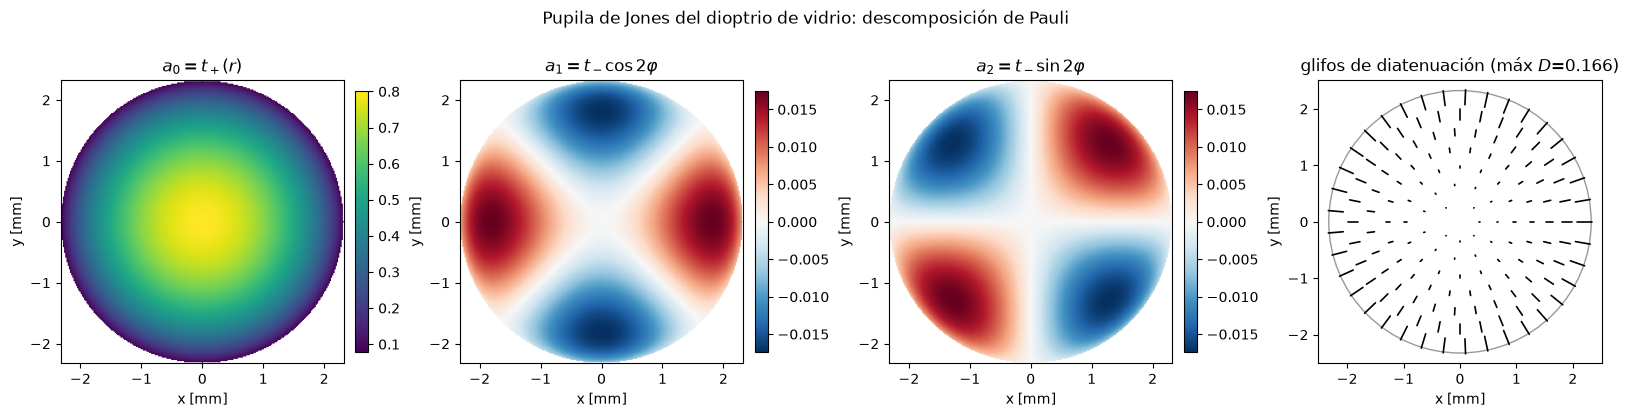

In [2]:
cs = case_g
a = cs["a"]
n_grid = 241
x = np.linspace(-a, a, n_grid)
X, Y = np.meshgrid(x, x)
Rg = np.hypot(X, Y)
PHI = np.arctan2(Y, X)
inside = Rg <= a

t_plus = 0.5 * (cs["tp"] + cs["ts"])
t_minus = 0.5 * (cs["tp"] - cs["ts"])
tp_g = np.where(inside, np.interp(Rg, cs["r"], t_plus), np.nan)
tm_g = np.where(inside, np.interp(Rg, cs["r"], t_minus), np.nan)

fig, axes = plt.subplots(1, 4, figsize=(16, 4.1), constrained_layout=True)
panels = [
    (tp_g, "viridis", None, r"$a_0 = t_+(r)$"),
    (tm_g * np.cos(2 * PHI), "RdBu_r", "sym", r"$a_1 = t_-\cos 2\varphi$"),
    (tm_g * np.sin(2 * PHI), "RdBu_r", "sym", r"$a_2 = t_-\sin 2\varphi$"),
]
for ax, (img, cmap, mode, title) in zip(axes[:3], panels):
    vmax = np.nanmax(np.abs(img))
    kw = dict(vmin=-vmax, vmax=vmax) if mode == "sym" else {}
    im = ax.imshow(img, extent=(-a, a, -a, a), origin="lower", cmap=cmap, **kw)
    ax.set(title=title, xlabel="x [mm]", ylabel="y [mm]", aspect="equal")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax = axes[3]
D_r = st.diattenuation(cs)
r_k = np.linspace(0.15, 0.95, 7) * a
seg = 0.5 * (r_k[1] - r_k[0])
for rk in r_k:
    Dk = np.interp(rk, cs["r"], D_r)
    n_phi = max(8, int(round(2 * np.pi * rk / (2.4 * seg))))
    for ph in np.linspace(0, 2 * np.pi, n_phi, endpoint=False):
        L = seg * Dk / D_r[-1]
        ax.plot([rk * np.cos(ph) - L * np.cos(ph), rk * np.cos(ph) + L * np.cos(ph)],
                [rk * np.sin(ph) - L * np.sin(ph), rk * np.sin(ph) + L * np.sin(ph)],
                "k-", lw=1.2, solid_capstyle="round")
circ = plt.Circle((0, 0), a, fill=False, color="0.6", lw=1)
ax.add_patch(circ)
ax.set(title=rf"glifos de diatenuación (máx $D$={D_r[-1]:.3f})",
       xlabel="x [mm]", ylabel="y [mm]", aspect="equal",
       xlim=(-1.08 * a, 1.08 * a), ylim=(-1.08 * a, 1.08 * a))
fig.suptitle("Pupila de Jones del dioptrio de vidrio: descomposición de Pauli", fontsize=12)
fig.savefig(out_dir / "04_jones_pupil.png", dpi=200)
plt.show()

El patrón es el del **diatenuador radial**: la aberración de polarización de
segundo orden de Chipman (tréboles $\cos2\varphi$/$\sin2\varphi$ en las
componentes de Pauli, glifos radiales que crecen cuadráticamente). Como
$t_p,t_s$ son reales, la retardancia es nula: toda la aberración de
polarización del dioptrio es diatenuación.

## Perfiles $D(r)$ y diatenuación RMS

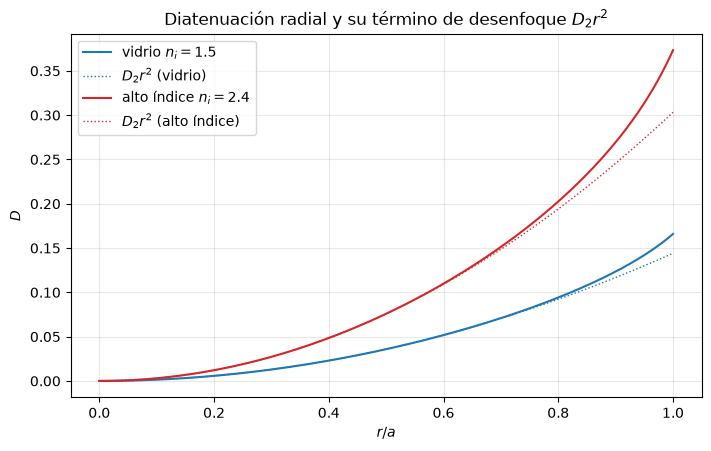

dioptrio                         D(a)  D_rms,inc  D_rms,tra   f_cross  D_rms²/4
vidrio n=1.5                   0.1660     0.1070     0.0657   0.00108   0.00108
alto índice n=2.4              0.3733     0.2224     0.1397   0.00498   0.00488


In [3]:
fig, ax = plt.subplots(figsize=(7, 4.4), constrained_layout=True)
rows = []
for cs, color, name in [(case_g, "C0", "vidrio $n_i=1.5$"), (case_h, "C3", "alto índice $n_i=2.4$")]:
    D = st.diattenuation(cs)
    ax.plot(cs["r"] / cs["a"], D, color=color, label=name)
    fit = st.fit_aberration_coefficients(cs)
    rr = cs["r"] / cs["a"]
    ax.plot(rr, fit["D2"] * cs["r"] ** 2, color=color, ls=":", lw=1,
            label=rf"$D_2 r^2$ ({name.split('$')[0].strip()})")
    rows.append((name, D[-1], st.diattenuation_rms(cs, "incident"),
                 st.diattenuation_rms(cs, "transmitted"), st.cross_fraction(cs)))
ax.set(xlabel="$r/a$", ylabel="$D$", title="Diatenuación radial y su término de desenfoque $D_2 r^2$")
ax.grid(alpha=0.3)
ax.legend()
fig.savefig(out_dir / "04_diattenuation.png", dpi=200)
plt.show()

print(f"{'dioptrio':28s} {'D(a)':>8s} {'D_rms,inc':>10s} {'D_rms,tra':>10s} {'f_cross':>9s} {'D_rms²/4':>9s}")
for name, De, Di, Dt, fc in rows:
    label = name.replace("$n_i=1.5$", "n=1.5").replace("$n_i=2.4$", "n=2.4")
    print(f"{label:28s} {De:8.4f} {Di:10.4f} {Dt:10.4f} {fc:9.5f} {Dt**2/4:9.5f}")

La última columna anticipa el resultado central de la sección siguiente:
$f_{\rm cross}\simeq D_{\rm rms}^2/4$ (con peso transmitido).

## $f_{\rm cross}$ es una función *exacta* de la diatenuación

Con $\varepsilon = t_-/t_+$ vale, punto a punto en la pupila,

$$ \frac{\varepsilon^2}{1+\varepsilon^2}
   \;=\; \frac{1-\sqrt{1-D^2}}{2}, $$

y $f_{\rm cross}$ es el cociente de Parseval
$\int t_-^2P^2 r\,dr / \int(t_+^2+t_-^2)P^2 r\,dr$, de modo que

$$ f_{\rm cross} \;=\;
   \Big\langle \tfrac{1}{2}\big(1-\sqrt{1-D^2}\,\big)\Big\rangle_w,
   \qquad w = (t_+^2+t_-^2)\,|P|^2\,r\,dr $$

**exactamente**, con $\langle D^2\rangle/4$ como primer término del
desarrollo. La energía cruzada del foco es, entonces, un puro funcional de
la diatenuación de Chipman de la pupila.

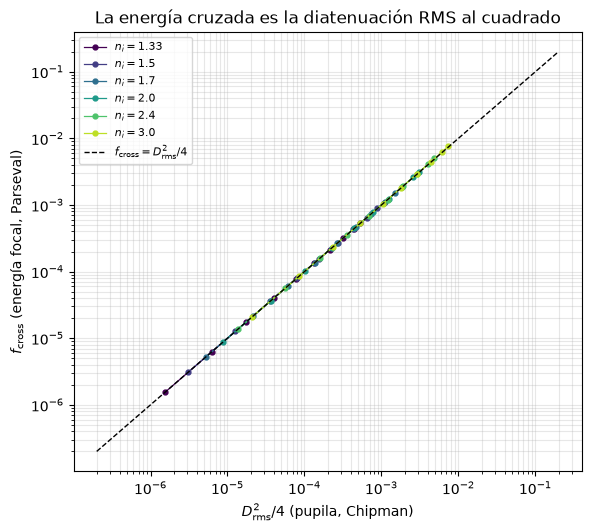

identidad exacta ⟨(1-√(1-D²))/2⟩ : desviación máxima 6.15e-13
orden dominante  D_rms²/4        : desviación máxima 3.5 % (peor caso: n_i=3, apertura rasante, D(a)=0.47)


In [4]:
nis = [1.33, 1.5, 1.7, 2.0, 2.4, 3.0]
fracs = np.linspace(0.2, 0.97, 10)
fig, ax = plt.subplots(figsize=(5.8, 5.2), constrained_layout=True)
worst_exact, worst_lead = 0.0, 0.0
for ni, color in zip(nis, plt.cm.viridis(np.linspace(0, 0.9, len(nis)))):
    xs, ys, es = [], [], []
    for fr in fracs:
        cs = st.spot_case(ni=ni, a_frac=fr, n_q=32, **base)
        xs.append(st.diattenuation_rms(cs, "transmitted") ** 2 / 4)
        ys.append(st.cross_fraction(cs))
        es.append(st.cross_fraction_from_diattenuation(cs))
    xs, ys, es = np.array(xs), np.array(ys), np.array(es)
    worst_exact = max(worst_exact, np.max(np.abs(es / ys - 1)))
    worst_lead = max(worst_lead, np.max(np.abs(ys / xs - 1)))
    ax.loglog(xs, ys, "o-", ms=3.5, lw=0.9, color=color, label=f"$n_i={ni}$")
lims = np.array([2e-7, 0.2])
ax.loglog(lims, lims, "k--", lw=1, label=r"$f_{\rm cross} = D_{\rm rms}^2/4$")
ax.set(xlabel=r"$D_{\rm rms}^2/4$ (pupila, Chipman)",
       ylabel=r"$f_{\rm cross}$ (energía focal, Parseval)",
       title="La energía cruzada es la diatenuación RMS al cuadrado")
ax.grid(alpha=0.3, which="both")
ax.legend(fontsize=8)
fig.savefig(out_dir / "04_fcross_vs_Drms.png", dpi=200)
plt.show()

print(f"identidad exacta ⟨(1-√(1-D²))/2⟩ : desviación máxima {worst_exact:.2e}")
print(f"orden dominante  D_rms²/4        : desviación máxima {100*worst_lead:.1f} % "
      f"(peor caso: n_i=3, apertura rasante, D(a)={st.diattenuation(st.spot_case(ni=3.0, a_frac=0.97, n_r=64, n_q=2, **base))[-1]:.2f})")
assert worst_exact < 1e-10

## Coeficientes de aberración: ajuste exacto vs. teoría paraxial

Para el dioptrio estigmático el desarrollo de segundo orden es

$$ \xi = \frac{n_0 (z_0-z_i)^2}{z_0^2 z_i^2 (n_0^2-n_i^2)},\qquad
   t_+ = \gamma_0 + (n_0{+}n_i)\tfrac{\xi}{2} r^2,\qquad
   t_- = (n_0{-}n_i)\tfrac{\xi}{2} r^2, $$

con $\gamma_0 = 2n_0/(n_0+n_i)$, de donde $D_2 = 2 d_2/\gamma_0
= (n_0-n_i)\,\xi/\gamma_0$. La tabla compara el ajuste por mínimos cuadrados
del Fresnel **exacto** (zona paraxial, $r\le 0.3a$) con estas fórmulas.

In [5]:
print(f"{'':14s} {'γ0':>9s} {'c2 [mm⁻²]':>11s} {'d2 [mm⁻²]':>11s} {'D2 [mm⁻²]':>11s}")
for cs, name in [(case_g, "vidrio"), (case_h, "alto índice")]:
    fit = st.fit_aberration_coefficients(cs)
    th = st.paraxial_theory(cs)
    print(f"{name:14s} {fit['g0']:9.5f} {fit['c2']:11.5f} {fit['d2']:11.5f} {fit['D2']:11.5f}   (ajuste)")
    print(f"{'':14s} {th['g0']:9.5f} {th['c2']:11.5f} {th['d2']:11.5f} {th['D2']:11.5f}   (teoría)")

                      γ0   c2 [mm⁻²]   d2 [mm⁻²]   D2 [mm⁻²]
vidrio           0.80000    -0.13106     0.01066     0.02665   (ajuste)
                 0.80000    -0.13111     0.01067     0.02667   (teoría)
alto índice      0.58823    -0.04260     0.00784     0.02665   (ajuste)
                 0.58824    -0.04262     0.00784     0.02667   (teoría)


### Nota: signo erróneo en `vecdiff.fresnel.FresnelOvoidParax`

Aquí hay que comparar cosa con cosa. `FresnelOvoidParax` desarrolla los
coeficientes de Fresnel **desnudos**, mientras que los canales que ve la
transformada focal llevan además $A(Q)$ y el jacobiano del mapeo. Los dos
desarrollos se comprueban por separado contra sus respectivos exactos.

In [6]:
from vecdiff.fresnel import FresnelOvoid, FresnelOvoidParax
from vecdiff.transfer import paraxial_channel_weights

surf_g = st.surface(case_g["n0"], case_g["ni"], case_g["z0"], case_g["zi"])
rr = case_g["r"]

# (a) coeficientes desnudos: paraxial del paquete vs. Fresnel exacto
ts_par, tp_par = FresnelOvoidParax(*[case_g[k] for k in ("n0", "ni", "z0", "zi")]).coeffs(rr)
tp_ex, ts_ex = FresnelOvoid(ovoid=surf_g).coefficients(rr)
small = rr < 0.3 * rr[-1]
print("t_p desnudo, pendiente r²: paraxial "
      f"{np.polyfit(rr[small]**2, tp_par[small], 1)[0]:+.5f} | exacto "
      f"{np.polyfit(rr[small]**2, tp_ex[small], 1)[0]:+.5f}")
print("t_s desnudo, pendiente r²: paraxial "
      f"{np.polyfit(rr[small]**2, ts_par[small], 1)[0]:+.5f} | exacto "
      f"{np.polyfit(rr[small]**2, ts_ex[small], 1)[0]:+.5f}")

# (b) pesos efectivos: expansión completa vs. ajuste del caso
wp_par, ws_par = paraxial_channel_weights(surf_g, rr)
fit = st.fit_aberration_coefficients(case_g)
print("t_+ efectivo, pendiente r²: paraxial "
      f"{np.polyfit(rr**2, 0.5 * (wp_par + ws_par), 1)[0]:+.5f} | ajuste {fit['c2']:+.5f}")
print("t_- efectivo, pendiente r²: paraxial "
      f"{np.polyfit(rr**2, 0.5 * (wp_par - ws_par), 1)[0]:+.5f} | ajuste {fit['d2']:+.5f}")

t_p desnudo, pendiente r²: paraxial -0.05689 | exacto -0.05844
t_s desnudo, pendiente r²: paraxial -0.08533 | exacto -0.08635
t_+ efectivo, pendiente r²: paraxial -0.13111 | ajuste -0.13106
t_- efectivo, pendiente r²: paraxial +0.01067 | ajuste +0.01066


## De la pupila al foco: predicción paraxial de la anisotropía

Con pupila uniforme y los $t_\pm$ paraxiales, los canales tienen forma
cerrada ($u = qa$, usando $\int_0^x x'^3 J_2\,dx' = x^3 J_3$):

$$ H_0 \simeq 2\gamma_0 a^2\,\frac{J_1(u)}{u},\qquad
   H_2 \simeq 2 d_2 a^4\,\frac{J_3(u)}{u}. $$

Sustituyendo en el predictor local del cuaderno 03,
$A_{\rm pred} = 4B(R_{\rm sca})/(|I'_{\rm sca}|R_{\rm sca})$ con
$\frac{d}{du}(J_1/u) = -J_2/u$, todo colapsa a una **forma cerrada**:

$$ \boxed{\;A \;\simeq\; \kappa\,\Delta_2,\qquad
   \Delta_2 = \frac{d_2 a^2}{\gamma_0} = \frac{D_2 a^2}{2},\qquad
   \kappa = \frac{2 J_3(u_h)}{u_h J_2(u_h)}\;} $$

evaluado en $u_h = 1.6163$ (HWHM de Airy): **la anisotropía del lóbulo es el
desenfoque de diatenuación acumulado en el borde de la pupila**, por una
constante universal de Bessel.

κ = 2 J3(u_h) / (u_h J2(u_h)) = 0.35322


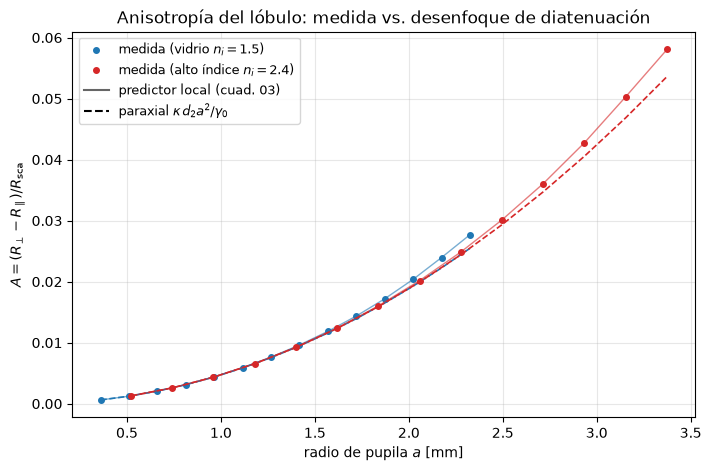

n_i=1.5: a=0.4·rasante → A medida 0.00435 | paraxial 0.00433 (-0.5 %)


n_i=2.4: a=0.4·rasante → A medida 0.00914 | paraxial 0.00911 (-0.2 %)


In [7]:
u_h = st.AIRY_HWHM
kappa = 2 * jv(3, u_h) / (u_h * jv(2, u_h))
print(f"κ = 2 J3(u_h) / (u_h J2(u_h)) = {kappa:.5f}")

fig, ax = plt.subplots(figsize=(7, 4.6), constrained_layout=True)
for ni, color, name in [(1.5, "C0", "vidrio $n_i=1.5$"), (2.4, "C3", "alto índice $n_i=2.4$")]:
    th = st.paraxial_theory(st.spot_case(ni=ni, a_frac=0.3, n_r=16, n_q=2, **base))
    fr_scan = np.linspace(0.15, 0.97, 14)
    A_meas, A_loc, A_par, avals = [], [], [], []
    for fr in fr_scan:
        cs = st.spot_case(ni=ni, a_frac=fr, **base)
        m = st.spot_metrics(cs)
        A_meas.append(m["anisotropy"])
        A_loc.append(st.anisotropy_prediction(cs))
        A_par.append(kappa * th["d2"] * cs["a"] ** 2 / th["g0"])
        avals.append(cs["a"])
    avals = np.array(avals)
    ax.plot(avals, A_meas, "o", ms=4, color=color, label=f"medida ({name})")
    ax.plot(avals, A_loc, "-", lw=1, color=color, alpha=0.6)
    ax.plot(avals, A_par, "--", lw=1.2, color=color)
ax.plot([], [], "k-", alpha=0.6, label="predictor local (cuad. 03)")
ax.plot([], [], "k--", label=r"paraxial $\kappa\,d_2 a^2/\gamma_0$")
ax.set(xlabel="radio de pupila $a$ [mm]", ylabel=r"$A = (R_\perp - R_\parallel)/R_{\rm sca}$",
       title="Anisotropía del lóbulo: medida vs. desenfoque de diatenuación")
ax.grid(alpha=0.3)
ax.legend(fontsize=9)
fig.savefig(out_dir / "04_paraxial_anisotropy.png", dpi=200)
plt.show()

for ni in (1.5, 2.4):
    cs = st.spot_case(ni=ni, a_frac=0.4, **base)
    th = st.paraxial_theory(cs)
    m = st.spot_metrics(cs)
    A_par = kappa * th["d2"] * cs["a"] ** 2 / th["g0"]
    print(f"n_i={ni}: a=0.4·rasante → A medida {m['anisotropy']:.5f} | paraxial {A_par:.5f} "
          f"({100 * (A_par / m['anisotropy'] - 1):+.1f} %)")

## Conclusiones

1. La pupila del dioptrio es, en el lenguaje de Chipman, un **diatenuador
   radial puro** (retardancia nula): $J = t_+\sigma_0 + t_-(\cos2\varphi\,
   \sigma_1+\sin2\varphi\,\sigma_2)$, y su orden más bajo es el *desenfoque
   de diatenuación* $D(r)\simeq D_2 r^2$.
2. Las métricas de Chipman **son** las cantidades focales de los cuadernos
   anteriores, en forma cuantitativa:
   - $f_{\rm cross} = \langle(1-\sqrt{1-D^2})/2\rangle_w$ **exactamente**
     (verificado a precisión de máquina en todo el atlas apertura × índice);
     su orden dominante $D_{\rm rms}^2/4$ ya da el valor a ~1 % en vidrio y
     solo se desvía (~11 %) en el extremo $n_i=3$ rasante, donde $D\to0.6$;
   - la anisotropía del lóbulo es $A \simeq \kappa\,D_2 a^2/2$ con
     $\kappa = 2J_3(u_h)/(u_h J_2(u_h)) \approx 0.353$: primer orden en la
     diatenuación, evaluada en el borde de la pupila.
3. El régimen paraxial reproduce el ajuste exacto de $(γ_0, c_2, d_2)$, pero
   la expansión tiene que incluir el factor geométrico $A(Q)$ y el jacobiano
   del mapeo, no solo los coeficientes de Fresnel: el canal cruzado gana un
   término puramente geométrico $γ_0(1/z_0^2 - 1/z_i^2)/4$. El signo erróneo
   que `FresnelOvoidParax` tenía en $t_s$ ya está corregido en el paquete —
   era solo el signo, los índices estaban bien.

**Referencia**: J. P. McGuire, R. A. Chipman, "Polarization aberrations. 1.
Rotationally symmetric optical systems", JOSA A **7**, 1614–1626 (1990).